# Within-Subject Spatial Kendall Evaluation

Kendall-rank reconstruction diagnostics split out from per-gene population evaluation.


## Table of Contents

- Notebook Configuration
- Shared Reconstruction
- Within-subject spatial Kendall-τ
- Sublist analysis


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as _np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
%matplotlib inline

import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eda_core as eda_core
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_style)
importlib.reload(eda_core)
importlib.reload(eval_population)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *

## Notebook Configuration


In [3]:
# === Global config ===
set_academic_style()

# Switch this one value when comparing cache families.
#   c        = centroid matching, covariate-aware ComBat
#   cv       = centroid+volume matching, covariate-aware ComBat
#   cv_nocov = centroid+volume matching, no ComBat covariates
CACHE_VARIANT = 'cv'  # 'c' | 'cv' | 'cv_nocov'
CACHE_VARIANTS = {
    'c': dict(
        cache_root='out/loro_subject_cache_c',
        combat_use_covariates=True,
        matching_policy='centroids',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv': dict(
        cache_root='out/loro_subject_cache_cv',
        combat_use_covariates=True,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv_nocov': dict(
        cache_root='out/loro_subject_cache_cv_nocov',
        combat_use_covariates=False,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
}
CACHE_CFG = CACHE_VARIANTS[CACHE_VARIANT]

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root=CACHE_CFG['cache_root'],
    gene_scope='allgenes',
    combat_use_covariates=CACHE_CFG['combat_use_covariates'],
    matching_policy=CACHE_CFG['matching_policy'],
    matching_policy_hemi_mode=CACHE_CFG['matching_policy_hemi_mode'],
    collapse_cerebellum=CACHE_CFG['collapse_cerebellum'],
    gtex_rep_mode='centroid',
    gtex_hemi_mode='mirror_left',
)
print('cache variant:', CACHE_VARIANT)
print('cache root:', CFG.cache_root)
print('analysis scope:', CFG.gene_scope)
print('combat_use_covariates:', CFG.combat_use_covariates)
print('matching:', CFG.matching_policy, CFG.matching_policy_hemi_mode, 'collapse_cerebellum=', CFG.collapse_cerebellum)

MODELS                       = ['naive', 'dlam', 'plam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = False

VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse


analysis scope: allgenes


## Shared Reconstruction

`PREPOST` + canonical wide truth/pred tables. The view used for the per-gene scoring is constructed in **Section 1** below using `GENE_LIST_PATH` so swapping panels is a single-cell edit.


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])

[prepost_cache] hit  notebooks/cache/prepost/0f8616c23cf88e0f.pkl  (8961.2 MB)
subjects: 318
genes: 11704
parcels: 150


In [5]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)
print({model: df.shape for model, df in pred_dfs.items()})

{'naive': (2869, 11722), 'dlam': (2869, 11722), 'plam': (2869, 11722)}


In [6]:
# Helper: build a gene-panel-scoped view from globals (truth_df / pred_dfs / VIEW_SUBSET).
# Keeps each section's setup to a single line.
def build_panel_view(gene_list_path=None, models=None, **overrides):
    subset = {**VIEW_SUBSET, **overrides}
    return make_prediction_eval_view(
        truth_df=truth_df, pred_dfs=pred_dfs,
        eval_gene_list_path=gene_list_path,
        models=list(models) if models is not None else MODELS,
        **subset,
    )


## Section 5 — Within-subject spatial Kendall-τ

Within each brain, is each gene predicted with the right *spatial ordering* across that subject's covered regions? We compute one Kendall-τ per `(subject, gene, model)` between truth and prediction across the subject's regions, then aggregate two ways:

- **Per-gene** — median across subjects → "how spatially predictable is gene G across brains?" (x = gene)
- **Per-subject** — median across genes → "how spatially predictable is the whole transcriptome within subject S?" (x = subject)

Median is used as the y-axis aggregation (NaN-robust to constant-truth genes); raw τ values are kept in the long table for downstream work.

**Compute cost:** ~250 subjects × N genes × 3 models scipy.kendalltau calls. HVG-100 finishes in seconds; all-genes is several minutes. Disk cache makes reruns instant.


In [20]:
# Section 5 config — within-subject Kendall-τ
KENDALL_GENE_LIST_PATH    = None        # default: ALL genes (cached once; sublists subset from there)
KENDALL_MIN_REGIONS       = 5           # subjects with k_s < this are dropped
KENDALL_FORCE_REBUILD     = False       # bypass disk cache

# Plot knobs (shared across the gene-wise + subject-wise ranked views)
KENDALL_METRIC_COL        = 'median'    # 'median' (default) | 'mean'
KENDALL_ANCHOR_MODEL      = 'naive'
KENDALL_SPARSIFY          = 100
KENDALL_BOTTOM_QUANTILE   = None        # no bottom-tail red shading by default
KENDALL_TOP_QUANTILE      = None


In [21]:
# Build the gene-panel view (None → all genes), then compute (cached on disk).
kendall_view = build_panel_view(KENDALL_GENE_LIST_PATH)
print('kendall view: subjects =', kendall_view['truth_df']['subject'].nunique(),
      ' genes =', len(kendall_view['genes']))

kendall_long = compute_within_subject_kendall(
    kendall_view,
    models=MODELS,
    min_regions=KENDALL_MIN_REGIONS,
    force_rebuild=KENDALL_FORCE_REBUILD,
)
print('kendall_long:', kendall_long.shape)
display(
    kendall_long.groupby('model', as_index=False).agg(
        n_pairs=('kendall_tau', 'size'),
        n_valid=('kendall_tau', lambda s: int(s.notna().sum())),
        median_tau=('kendall_tau', 'median'),
        mean_tau=('kendall_tau', 'mean'),
    )
)


kendall view: subjects = 318  genes = 11704
[kendall_cache] hit  notebooks/cache/genewise_kendall/df98ceb56ef763cf.pkl  (307.6 MB)
kendall_long: (11165616, 5)


,model,n_pairs,n_valid,median_tau,mean_tau
0,dlam,3721872,3721872,0.155556,0.114734
1,naive,3721872,3721872,0.181818,0.172181
2,plam,3721872,3721872,0.066667,0.063489


In [22]:
kendall_per_gene    = summarize_kendall_per_unit(kendall_long, unit_col='gene')
kendall_per_subject = summarize_kendall_per_unit(kendall_long, unit_col='subject')
print('per-gene summary:   ', kendall_per_gene.shape)
print('per-subject summary:', kendall_per_subject.shape)
display(kendall_per_gene.head())
display(kendall_per_subject.head())

per-gene summary:    (35112, 7)
per-subject summary: (954, 7)


,model,gene,median,mean,std,n_subject,n_valid
0,dlam,A1BG,0.111111,0.084518,0.305317,318,318
1,dlam,A1BG-AS1,0.244444,0.212218,0.324541,318,318
2,dlam,AAAS,0.200000,0.161600,0.302697,318,318
3,dlam,AACS,0.277778,0.244109,0.277290,318,318
4,dlam,AADAT,0.333333,0.274597,0.298616,318,318


,model,subject,median,mean,std,n_gene,n_valid
0,dlam,GTEX-1117F,0.111111,0.093451,0.313003,11704,11704
1,dlam,GTEX-111FC,0.200000,0.183063,0.296580,11704,11704
2,dlam,GTEX-117XS,0.212121,0.183746,0.171472,11704,11704
3,dlam,GTEX-1192W,0.200000,-0.002818,0.403452,11704,11704
4,dlam,GTEX-1192X,0.090909,0.076024,0.238588,11704,11704


### Gene-wise ranked (median Kendall-τ across subjects)

One x position per gene; the same gene occupies the same x position under every model since subjects are ordered by anchor model's median.


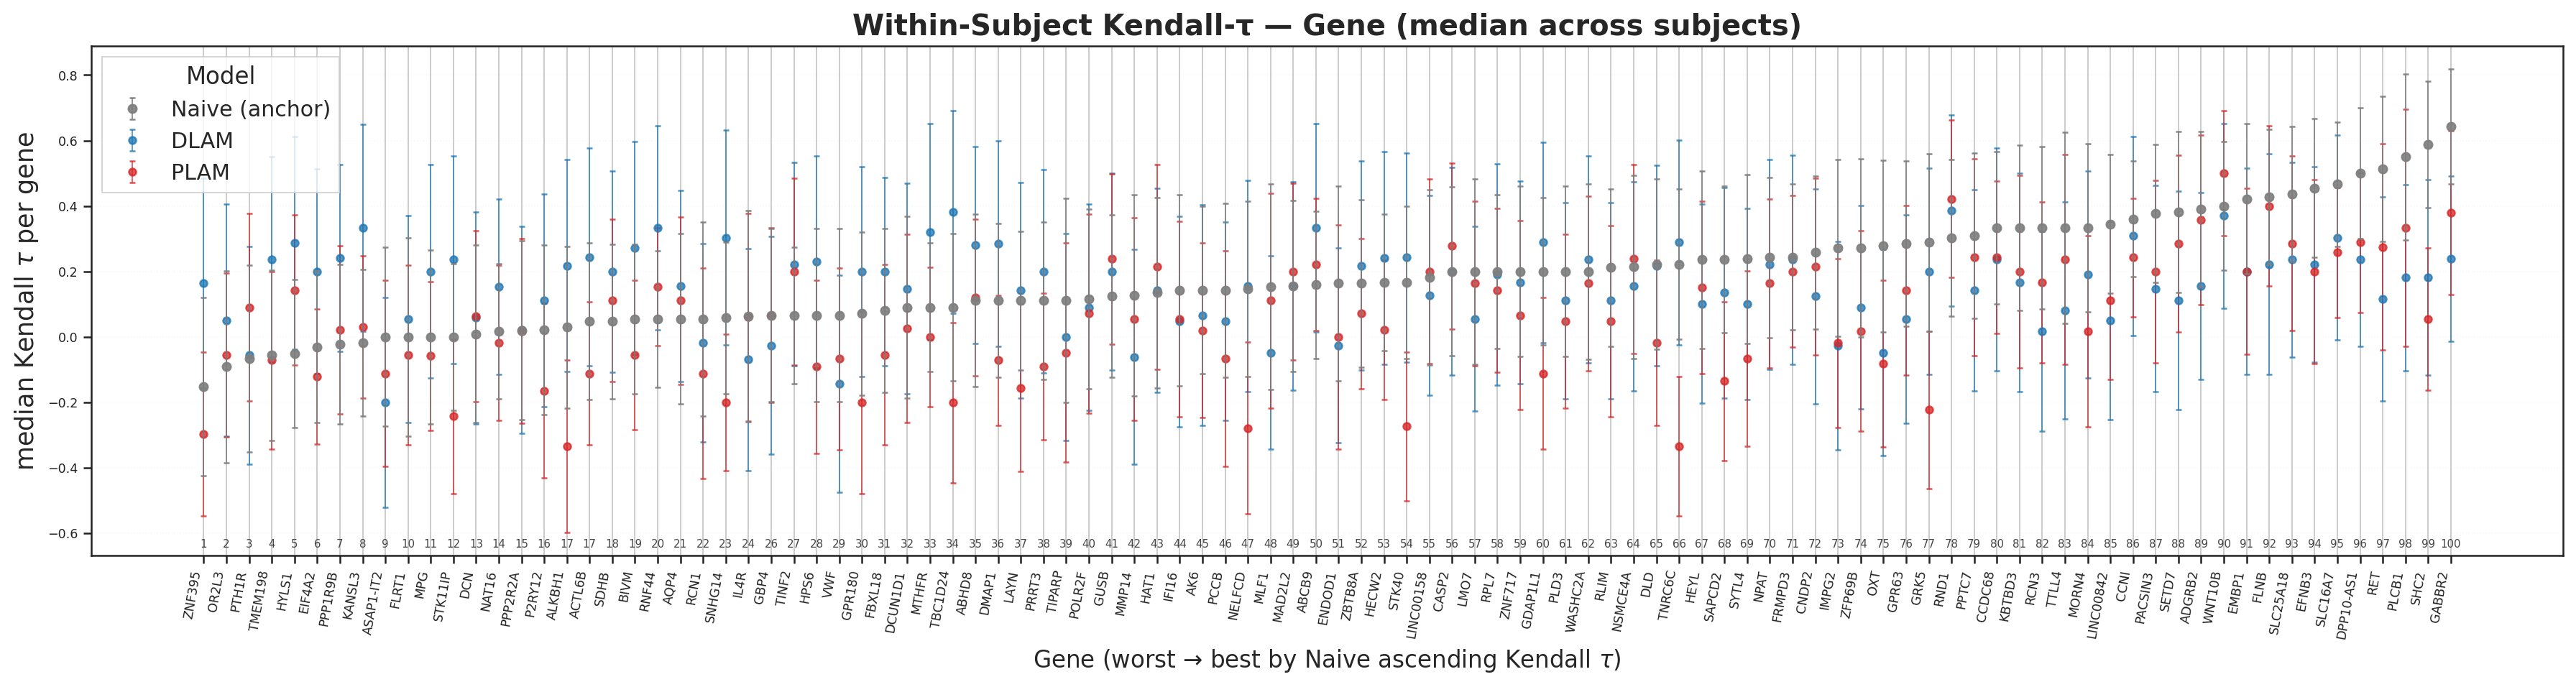

In [23]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_gene,
    unit_col='gene',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)

### Subject-wise ranked (median Kendall-τ across genes)


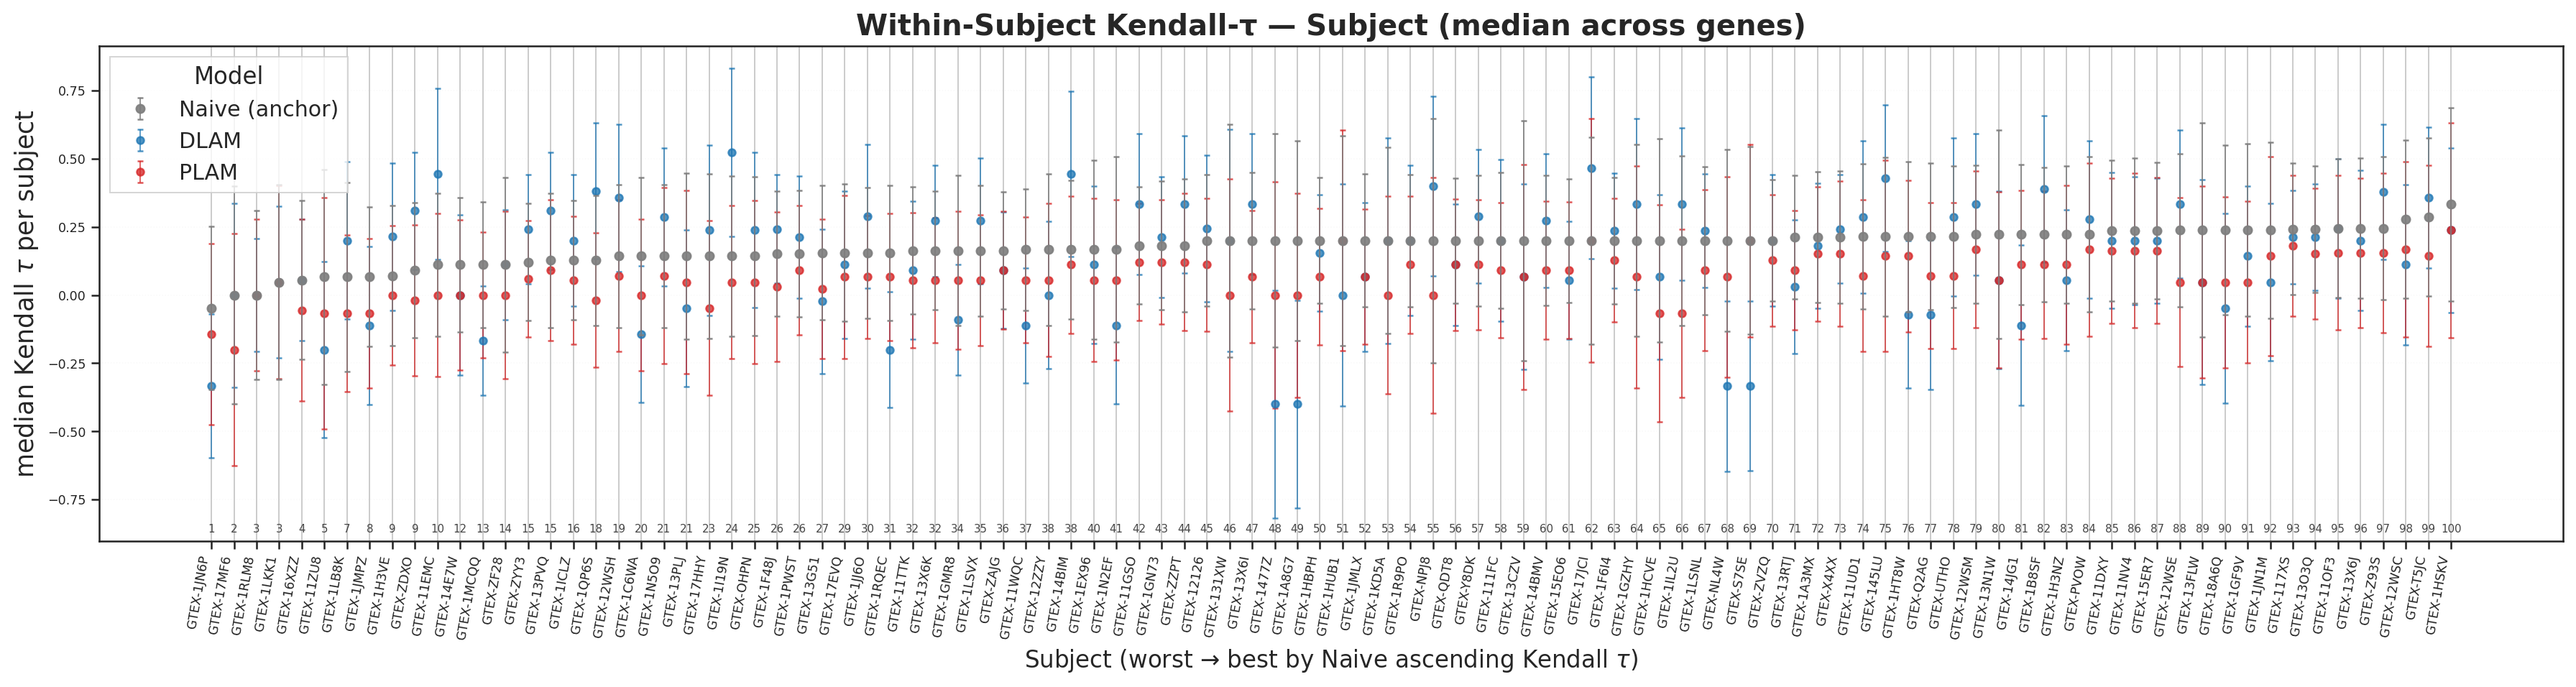

In [24]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_subject,
    unit_col='subject',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)

### Sublist analysis (no recompute)

Filter the cached all-genes Kendall long table to a sublist (default: `gtex_100hvg`) via `filter_kendall_to_genes` and re-aggregate / re-plot. Free — no scipy calls.


In [25]:
# Kendall sublist config — repurposes the cached all-genes long table.
KENDALL_SUBLIST_PATH      = 'gtex_100hvg'   # any path/basename, or list of gene names
KENDALL_SUBLIST_SPARSIFY  = None            # smaller panels usually fit without sparsifying


In [26]:
# Resolve the sublist's gene names from the panel path.
_sublist_genes = list(build_panel_view(KENDALL_SUBLIST_PATH)['genes'])
kendall_long_sublist = filter_kendall_to_genes(kendall_long, _sublist_genes)
print(f'kendall_long_sublist: {kendall_long_sublist.shape}  ({len(_sublist_genes)} genes in panel)')

kendall_per_gene_sublist    = summarize_kendall_per_unit(kendall_long_sublist, unit_col='gene')
kendall_per_subject_sublist = summarize_kendall_per_unit(kendall_long_sublist, unit_col='subject')


kendall_long_sublist: (89676, 5)  (94 genes in panel)


#### Sublist gene-wise ranked


Text(0.5, 1.0, 'Within-Subject Kendall-τ — Gene (median across subjects)  (gtex_100hvg)')

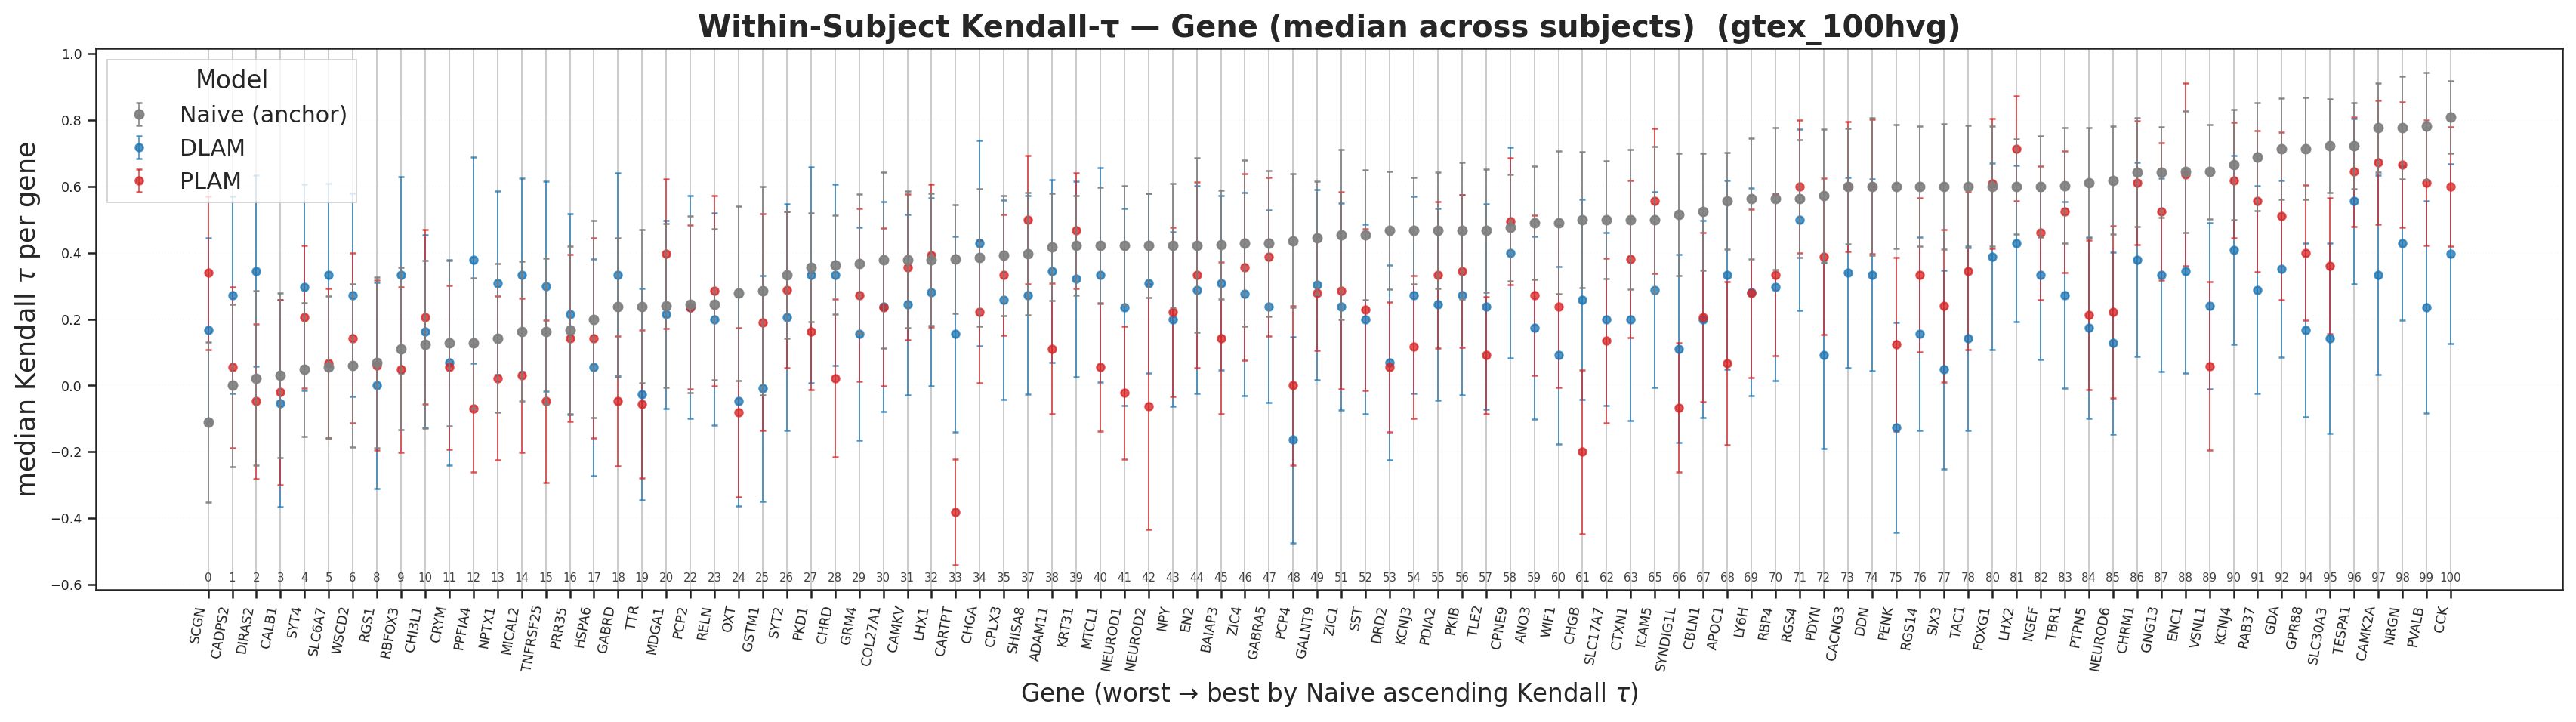

In [27]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_gene_sublist,
    unit_col='gene',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SUBLIST_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)
ax.set_title(
    f"{ax.get_title()}  ({KENDALL_SUBLIST_PATH})",
    fontsize=ax.title.get_fontsize(),
)


#### Sublist subject-wise ranked


Text(0.5, 1.0, 'Within-Subject Kendall-τ — Subject (median across genes)  (gtex_100hvg)')

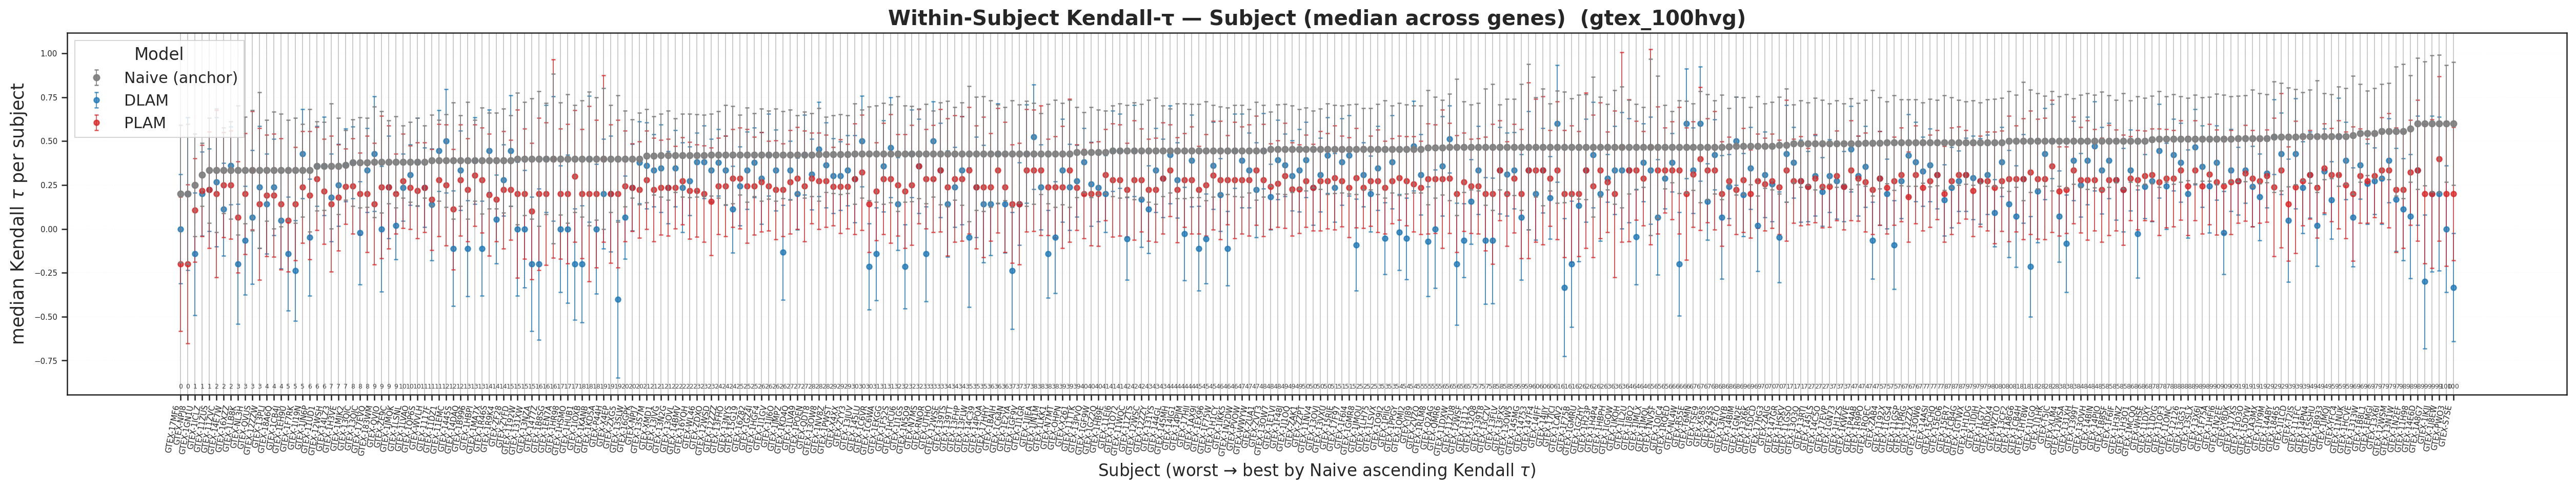

In [28]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_subject_sublist,
    unit_col='subject',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SUBLIST_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)
ax.set_title(
    f"{ax.get_title()}  ({KENDALL_SUBLIST_PATH})",
    fontsize=ax.title.get_fontsize(),
)
